In [1]:
!pip install -q datasets

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from datasets import load_dataset
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cpu


In [4]:
print("Loading AG News Dataset...")

dataset = load_dataset("fancyzhx/ag_news")

train_data = dataset["train"]
test_data  = dataset["test"]

print("Training Samples :", len(train_data))
print("Testing Samples  :", len(test_data))

# Display class distribution
label_names = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
from collections import Counter
label_counts = Counter(train_data["label"])
print("\nClass Distribution in Training Set:")
for lbl, cnt in sorted(label_counts.items()):
    print(f"  {label_names[lbl]}: {cnt} samples")

Loading AG News Dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Training Samples : 120000
Testing Samples  : 7600

Class Distribution in Training Set:
  World: 30000 samples
  Sports: 30000 samples
  Business: 30000 samples
  Sci/Tech: 30000 samples


In [5]:
print("Building Vocabulary...")

vocab = {
    "<unk>": 0,
    "<pad>": 1
}

def tokenize(text):
    return text.lower().split()

for article in train_data["text"]:
    words = tokenize(article)

    for word in words:
        if word not in vocab:
            vocab[word] = len(vocab)

print("Vocabulary Size:", len(vocab))

PAD_IDX = vocab["<pad>"]

Building Vocabulary...
Vocabulary Size: 158735


In [6]:
def numericalize(text):
    words = tokenize(text)

    return [
        vocab.get(word, vocab["<unk>"])
        for word in words
    ]

In [7]:
def collate_batch(batch):

    text_list = []
    label_list = []
    length_list = []

    for item in batch:

        text_tensor = torch.tensor(
            numericalize(item["text"]),
            dtype=torch.long
        )

        text_list.append(text_tensor)
        label_list.append(item["label"])
        length_list.append(len(text_tensor))

    padded_texts = pad_sequence(
        text_list,
        batch_first=True,
        padding_value=PAD_IDX
    )

    return (
        padded_texts.to(device),
        torch.tensor(label_list).to(device),
        torch.tensor(length_list)
    )

In [8]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_batch
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch
)

In [9]:
class NewsRNNModel(nn.Module):

    def __init__(self, vocab_size):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            100,
            padding_idx=PAD_IDX
        )

        self.rnn = nn.RNN(
            input_size=100,
            hidden_size=128,
            batch_first=True
        )

        self.fc = nn.Linear(128, 4)

    def forward(self, text, lengths):

        embedded = self.embedding(text)

        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, hidden = self.rnn(packed)

        hidden = hidden.squeeze(0)

        return self.fc(hidden)


In [10]:
model = NewsRNNModel(vocab_size=len(vocab)).to(device)

print("Model Architecture:")
print(model)
print(f"\nTotal Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model Architecture:
NewsRNNModel(
  (embedding): Embedding(158735, 100, padding_idx=1)
  (rnn): RNN(100, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)

Total Trainable Parameters: 15,903,456


In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


In [12]:
def train():

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for texts, labels, lengths in train_loader:

        optimizer.zero_grad()

        outputs = model(texts, lengths)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

    accuracy = 100 * correct / total

    return total_loss, accuracy

In [13]:
def evaluate():

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for texts, labels, lengths in test_loader:

            outputs = model(texts, lengths)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()

            total += labels.size(0)

    accuracy = 100 * correct / total

    return accuracy

In [14]:
EPOCHS = 5

train_loss_history = []
train_acc_history  = []
test_acc_history   = []

print("\nStarting Training...\n")

for epoch in range(EPOCHS):

    train_loss, train_acc = train()
    test_acc = evaluate()

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.2f}% "
        f"Test Acc: {test_acc:.2f}%"
    )



Starting Training...

Epoch [1/5] Loss: 1718.8196 Train Acc: 61.27% Test Acc: 67.82%
Epoch [2/5] Loss: 1611.0348 Train Acc: 64.56% Test Acc: 79.17%
Epoch [3/5] Loss: 933.8041 Train Acc: 82.68% Test Acc: 80.05%
Epoch [4/5] Loss: 901.4221 Train Acc: 83.34% Test Acc: 82.42%
Epoch [5/5] Loss: 721.7346 Train Acc: 87.26% Test Acc: 83.05%


In [15]:
torch.save(
    model.state_dict(),
    "news_classifier_rnn.pth"
)

print("\nModel saved as news_classifier_rnn.pth")


Model saved as news_classifier_rnn.pth


In [16]:
categories = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

def predict_news(text):

    model.eval()

    tokens = torch.tensor(
        [numericalize(text)],
        dtype=torch.long
    ).to(device)

    lengths = torch.tensor(
        [tokens.size(1)]
    )

    with torch.no_grad():

        output = model(tokens, lengths)

        prediction = output.argmax(dim=1).item()

    return categories[prediction]

In [17]:
sample_news = """
The central bank raised interest rates by 50 basis points
to combat rising inflation across global markets.
"""

predicted_label = predict_news(sample_news)

print("\nInput News Headline:")
print(sample_news)
print("Predicted Category:", predicted_label)



Input News Headline:

The central bank raised interest rates by 50 basis points
to combat rising inflation across global markets.

Predicted Category: Business


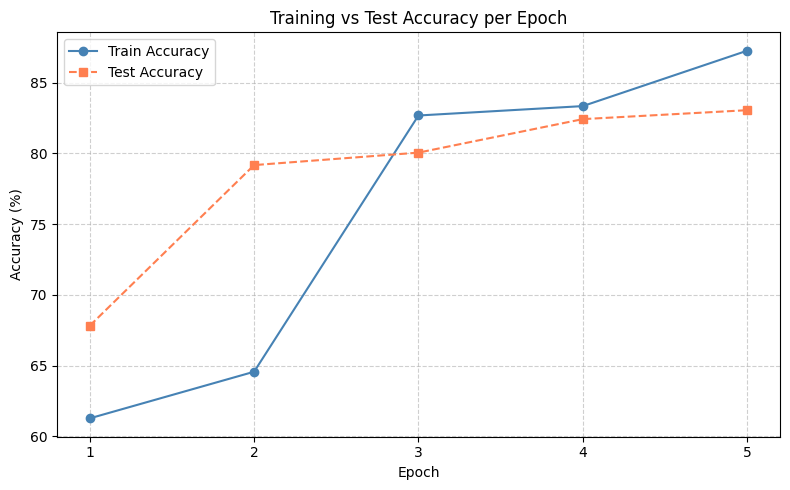

In [18]:
# Training vs Test Accuracy over Epochs
epochs_range = list(range(1, EPOCHS + 1))

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_acc_history, marker='o', label='Train Accuracy', color='steelblue')
plt.plot(epochs_range, test_acc_history,  marker='s', label='Test Accuracy',  color='coral', linestyle='--')
plt.title('Training vs Test Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.xticks(epochs_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


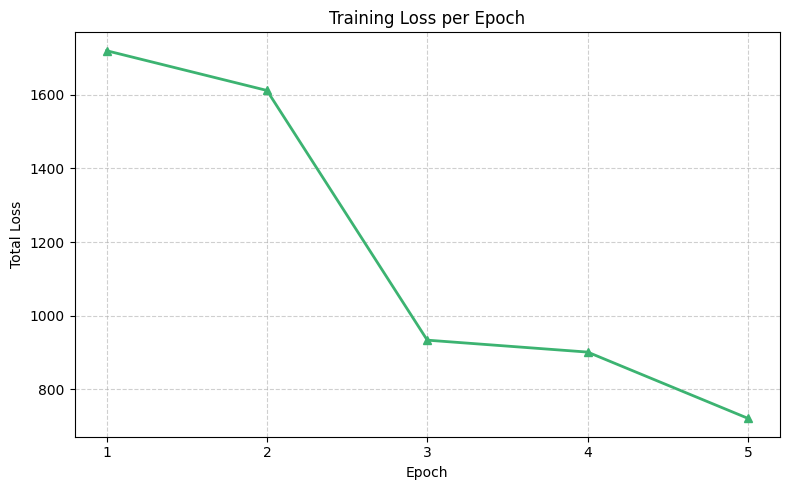

In [19]:
# Training Loss over Epochs
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_loss_history, marker='^', color='mediumseagreen', linewidth=2)
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.xticks(epochs_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
